# Частотный конвертер (Sample Rate Converter)

Реализация частотного конвертера для преобразования частоты дискретизации аудио сигналов.

## Этапы реализации:
1. **Растяжение** - вставка нулей между отсчетами
2. **Фильтрация** - применение идеального фильтра
3. **Прореживание** - выборка отсчетов с шагом


In [ ]:
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from scipy import signal
from IPython.display import Audio, display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


## Загрузка тестового файла


In [16]:
# Загрузка исходного аудио файла
audio_file = 'my_voice.wav'
x_original, sr_original = sf.read(audio_file)

print(f"Исходная частота дискретизации: {sr_original} Hz")
print(f"Длина сигнала: {len(x_original)} отсчетов")
print(f"Длительность: {len(x_original) / sr_original:.2f} секунд")
print(f"Форма сигнала: {x_original.shape}")

# Если стерео, возьмем только один канал
if len(x_original.shape) > 1:
    x_original = x_original[:, 0]
    print("Взят только первый канал (моно)")

# Нормализация
x_original = x_original.astype(np.float32)


Исходная частота дискретизации: 44100 Hz
Длина сигнала: 251391 отсчетов
Длительность: 5.70 секунд
Форма сигнала: (251391, 2)
Взят только первый канал (моно)


## Реализация частотного конвертера

### Оптимизированная реализация с поточечной обработкой


In [17]:
def frequency_converter_optimized(x, N1, N2, filter_type='fir', filter_order=101):
    """
    Частотный конвертер, реализующий три этапа:
    1. Растяжение - вставка нулей между отсчетами по правилу (2)
    2. Фильтрация - применение идеального фильтра (приближение к (3))
    3. Прореживание - выборка отсчетов с шагом N1
    
    Параметры:
    ----------
    x : array_like
        Входной сигнал
    N1 : int
        Исходная частота дискретизации
    N2 : int
        Целевая частота дискретизации
    filter_type : str
        Тип фильтра: 'fir' (КИХ) или 'iir' (БИХ)
    filter_order : int
        Порядок фильтра (для FIR) или количество секций (для IIR)
    
    Возвращает:
    -----------
    y : ndarray
        Преобразованный сигнал
    """
    # Находим НОД для упрощения отношения частот
    from math import gcd
    gcd_val = gcd(N1, N2)
    N1_simplified = N1 // gcd_val
    N2_simplified = N2 // gcd_val
    
    # Определяем режим работы
    if N1_simplified > N2_simplified:
        # Случай понижения частоты (N1 > N2)
        # Этап 1: Растяжение - вставляем нули между отсчетами
        # По правилу (2): x̂(j) = x(j/N2) если j делится на N2, иначе 0
        # Между каждой парой значений исходного сигнала будет вставлено N2_simplified - 1 нулей
        x_stretched = np.zeros(len(x) * N2_simplified, dtype=np.float32)
        x_stretched[::N2_simplified] = x
        
        # После растяжения: растянутый сигнал имеет частоту N1 * N2_simplified
        # (вставляем N2_simplified отсчетов на каждый исходный отсчет)
        # Этап 2: Фильтрация - антиалиасинг фильтр
        # Частота среза должна быть меньше целевой частоты Найквиста (N2/2)
        fs_stretched = N1 * N2_simplified  # Частота растянутого сигнала
        cutoff_hz = (N2 / 2) * 0.9  # Частота среза в Hz (90% от целевой частоты Найквиста)
        
        if filter_type == 'fir':
            # FIR фильтр (КИХ) - линейная фаза, лучше для качества
            h = signal.firwin(filter_order, cutoff_hz, fs=fs_stretched, window='hamming')
            y_filtered = signal.lfilter(h, 1, x_stretched)
        else:
            # IIR фильтр (БИХ) - более эффективный по вычислениям
            sos = signal.butter(filter_order, cutoff_hz, fs=fs_stretched, output='sos')
            y_filtered = signal.sosfilt(sos, x_stretched)
        
        # Этап 3: Прореживание - берем каждый N1_simplified-й отсчет
        # y(j) = ŷ(j * N1_simplified)
        y = y_filtered[::N1_simplified]
    
    else:
        # Случай повышения частоты (N1 < N2)
        # Этап 1: Растяжение - вставляем нули между отсчетами
        # По правилу (2): x̂(j) = x(j/N2) если j делится на N2, иначе 0
        # Для повышения частоты правильная интерпретация:
        # Создаем растянутый сигнал длиной len(x) * N2_simplified
        # Вставляем значения x в позиции, кратные N2_simplified
        x_stretched = np.zeros(len(x) * N2_simplified, dtype=np.float32)
        x_stretched[::N2_simplified] = x
        
        # После растяжения: растянутый сигнал имеет частоту N1 * N2_simplified
        # Этап 2: Фильтрация - интерполяционный фильтр
        # Частота среза ограничена исходной частотой Найквиста (N1/2)
        # Фильтр работает на частоте растянутого сигнала
        fs_stretched = N1 * N2_simplified  # Частота растянутого сигнала
        cutoff_hz = (N1 / 2) * 0.9  # Частота среза в Hz (90% от исходной частоты Найквиста)
        
        if filter_type == 'fir':
            # FIR фильтр
            h = signal.firwin(filter_order, cutoff_hz, fs=fs_stretched, window='hamming')
            y_filtered = signal.lfilter(h, 1, x_stretched)
        else:
            # IIR фильтр
            sos = signal.butter(filter_order, cutoff_hz, fs=fs_stretched, output='sos')
            y_filtered = signal.sosfilt(sos, x_stretched)
        
        # Этап 3: Прореживание - берем каждый N1_simplified-й отсчет
        # Это дает правильную длину: len(x) * N2_simplified / N1_simplified = len(x) * N2 / N1
        y = y_filtered[::N1_simplified]
    
    return y


In [18]:
# Тест 1: 22050 → 16000
print("=" * 60)
print("Тест 1: 22050 Hz → 16000 Hz")
print("=" * 60)

# Если исходная частота не 22050, передискретизируем для теста
if sr_original != 22050:
    x_test1 = librosa.resample(x_original, orig_sr=sr_original, target_sr=22050)
    sr_test1 = 22050
else:
    x_test1 = x_original.copy()
    sr_test1 = sr_original

N1_test1 = 22050
N2_test1 = 16000

print(f"Исходная частота: {N1_test1} Hz")
print(f"Целевая частота: {N2_test1} Hz")
print(f"Длина исходного сигнала: {len(x_test1)} отсчетов")

# Тестируем с FIR фильтром
y_fir_1 = frequency_converter_optimized(x_test1, N1_test1, N2_test1, 
                                         filter_type='fir', filter_order=101)
print(f"Длина преобразованного сигнала (FIR): {len(y_fir_1)} отсчетов")
print(f"Ожидаемая длина: {len(x_test1) * N2_test1 // N1_test1} отсчетов")

# Тестируем с IIR фильтром
y_iir_1 = frequency_converter_optimized(x_test1, N1_test1, N2_test1, 
                                         filter_type='iir', filter_order=8)
print(f"Длина преобразованного сигнала (IIR): {len(y_iir_1)} отсчетов")

# Сравнение с librosa
y_librosa_1 = librosa.resample(x_test1, orig_sr=N1_test1, target_sr=N2_test1)
print(f"Длина сигнала librosa: {len(y_librosa_1)} отсчетов")


Тест 1: 22050 Hz → 16000 Hz
Исходная частота: 22050 Hz
Целевая частота: 16000 Hz
Длина исходного сигнала: 125696 отсчетов
Длина преобразованного сигнала (FIR): 91208 отсчетов
Ожидаемая длина: 91207 отсчетов
Длина преобразованного сигнала (IIR): 91208 отсчетов
Длина сигнала librosa: 91208 отсчетов


In [19]:
# Тест 2: 44100 → 8000
print("\n" + "=" * 60)
print("Тест 2: 44100 Hz → 8000 Hz")
print("=" * 60)

# Передискретизируем для теста
x_test2 = librosa.resample(x_original, orig_sr=sr_original, target_sr=44100)
sr_test2 = 44100

N1_test2 = 44100
N2_test2 = 8000

print(f"Исходная частота: {N1_test2} Hz")
print(f"Целевая частота: {N2_test2} Hz")
print(f"Длина исходного сигнала: {len(x_test2)} отсчетов")

# Тестируем с FIR фильтром
y_fir_2 = frequency_converter_optimized(x_test2, N1_test2, N2_test2, 
                                         filter_type='fir', filter_order=201)
print(f"Длина преобразованного сигнала (FIR): {len(y_fir_2)} отсчетов")
print(f"Ожидаемая длина: {len(x_test2) * N2_test2 // N1_test2} отсчетов")

# Тестируем с IIR фильтром
y_iir_2 = frequency_converter_optimized(x_test2, N1_test2, N2_test2, 
                                         filter_type='iir', filter_order=8)
print(f"Длина преобразованного сигнала (IIR): {len(y_iir_2)} отсчетов")

# Сравнение с librosa
y_librosa_2 = librosa.resample(x_test2, orig_sr=N1_test2, target_sr=N2_test2)
print(f"Длина сигнала librosa: {len(y_librosa_2)} отсчетов")



Тест 2: 44100 Hz → 8000 Hz
Исходная частота: 44100 Hz
Целевая частота: 8000 Hz
Длина исходного сигнала: 251391 отсчетов
Длина преобразованного сигнала (FIR): 45604 отсчетов
Ожидаемая длина: 45603 отсчетов
Длина преобразованного сигнала (IIR): 45604 отсчетов
Длина сигнала librosa: 45604 отсчетов


## Задание 2: Реализация для случая N1 < N2 (повышение частоты)

Примеры: 8000 → 22050, 16000 → 44100


In [20]:
# Тест 3: 8000 → 22050
print("=" * 60)
print("Тест 3: 8000 Hz → 22050 Hz")
print("=" * 60)

# Передискретизируем для теста
x_test3 = librosa.resample(x_original, orig_sr=sr_original, target_sr=8000)
sr_test3 = 8000

N1_test3 = 8000
N2_test3 = 22050

print(f"Исходная частота: {N1_test3} Hz")
print(f"Целевая частота: {N2_test3} Hz")
print(f"Длина исходного сигнала: {len(x_test3)} отсчетов")

# Тестируем с FIR фильтром
y_fir_3 = frequency_converter_optimized(x_test3, N1_test3, N2_test3, 
                                         filter_type='fir', filter_order=101)
print(f"Длина преобразованного сигнала (FIR): {len(y_fir_3)} отсчетов")
print(f"Ожидаемая длина: {len(x_test3) * N2_test3 // N1_test3} отсчетов")

# Тестируем с IIR фильтром
y_iir_3 = frequency_converter_optimized(x_test3, N1_test3, N2_test3, 
                                         filter_type='iir', filter_order=8)
print(f"Длина преобразованного сигнала (IIR): {len(y_iir_3)} отсчетов")

# Сравнение с librosa
y_librosa_3 = librosa.resample(x_test3, orig_sr=N1_test3, target_sr=N2_test3)
print(f"Длина сигнала librosa: {len(y_librosa_3)} отсчетов")


Тест 3: 8000 Hz → 22050 Hz
Исходная частота: 8000 Hz
Целевая частота: 22050 Hz
Длина исходного сигнала: 45604 отсчетов
Длина преобразованного сигнала (FIR): 125697 отсчетов
Ожидаемая длина: 125696 отсчетов
Длина преобразованного сигнала (IIR): 125697 отсчетов
Длина сигнала librosa: 125697 отсчетов


In [21]:
# Тест 4: 16000 → 44100
print("\n" + "=" * 60)
print("Тест 4: 16000 Hz → 44100 Hz")
print("=" * 60)

# Передискретизируем для теста
x_test4 = librosa.resample(x_original, orig_sr=sr_original, target_sr=16000)
sr_test4 = 16000

N1_test4 = 16000
N2_test4 = 44100

print(f"Исходная частота: {N1_test4} Hz")
print(f"Целевая частота: {N2_test4} Hz")
print(f"Длина исходного сигнала: {len(x_test4)} отсчетов")

# Тестируем с FIR фильтром
y_fir_4 = frequency_converter_optimized(x_test4, N1_test4, N2_test4, 
                                         filter_type='fir', filter_order=201)
print(f"Длина преобразованного сигнала (FIR): {len(y_fir_4)} отсчетов")
print(f"Ожидаемая длина: {len(x_test4) * N2_test4 // N1_test4} отсчетов")

# Тестируем с IIR фильтром
y_iir_4 = frequency_converter_optimized(x_test4, N1_test4, N2_test4, 
                                         filter_type='iir', filter_order=8)
print(f"Длина преобразованного сигнала (IIR): {len(y_iir_4)} отсчетов")

# Сравнение с librosa
y_librosa_4 = librosa.resample(x_test4, orig_sr=N1_test4, target_sr=N2_test4)
print(f"Длина сигнала librosa: {len(y_librosa_4)} отсчетов")



Тест 4: 16000 Hz → 44100 Hz
Исходная частота: 16000 Hz
Целевая частота: 44100 Hz
Длина исходного сигнала: 91208 отсчетов
Длина преобразованного сигнала (FIR): 251393 отсчетов
Ожидаемая длина: 251392 отсчетов
Длина преобразованного сигнала (IIR): 251393 отсчетов
Длина сигнала librosa: 251393 отсчетов


## Задание 3: Эксперименты с различными фильтрами

Сравнение FIR (КИХ) и IIR (БИХ) фильтров для обоих случаев


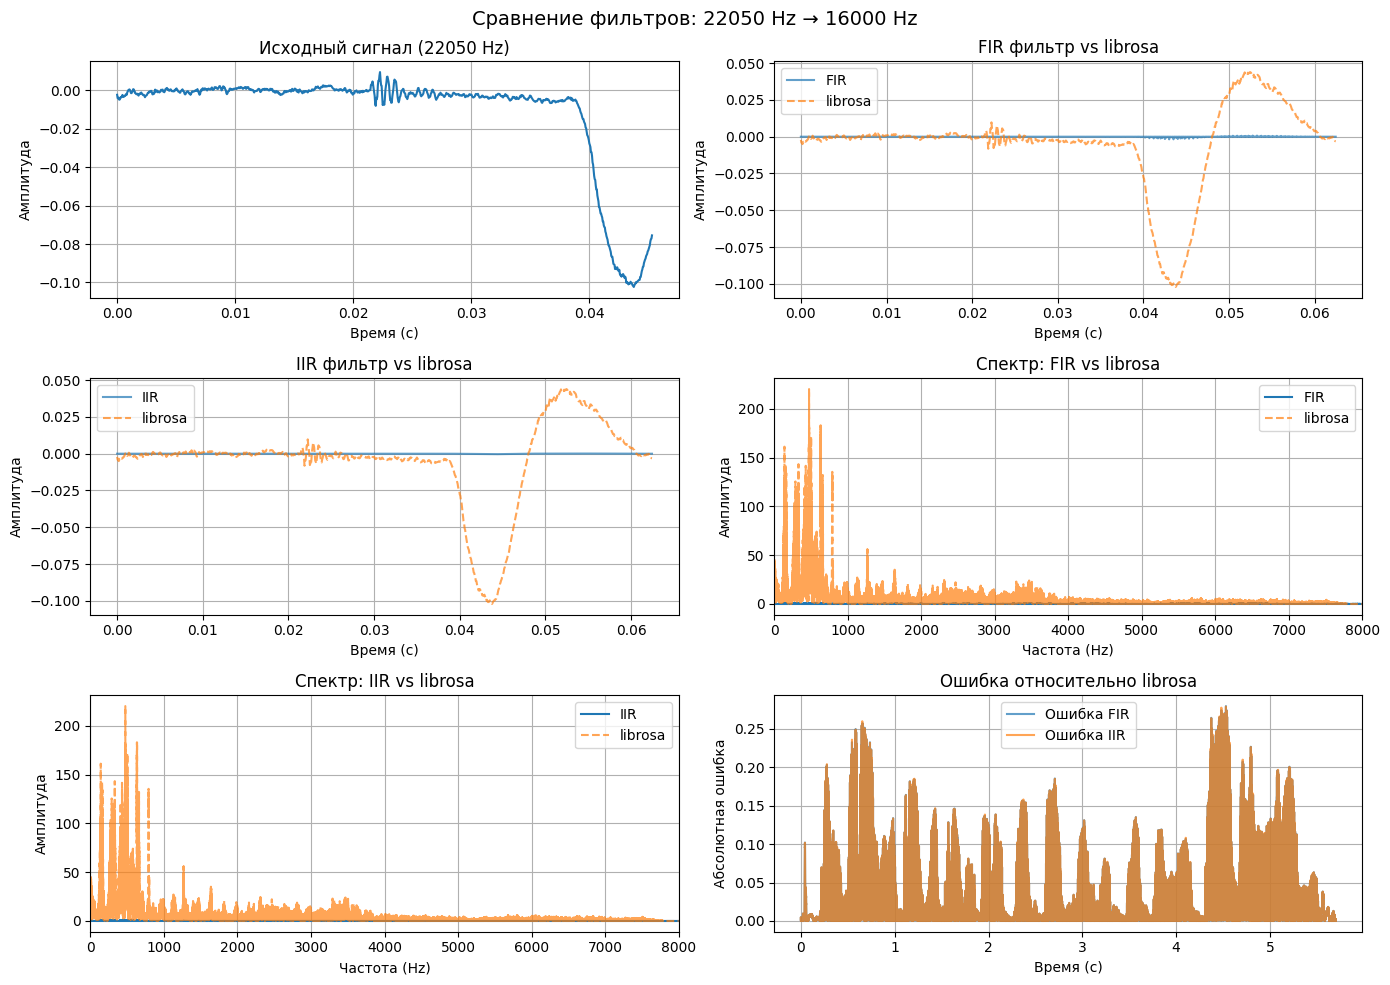

In [22]:
# Визуализация результатов для случая N1 > N2 (22050 → 16000)
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Сравнение фильтров: 22050 Hz → 16000 Hz', fontsize=14)

# Временная область - первые 1000 отсчетов
start_idx = 0
end_idx = min(1000, len(x_test1), len(y_fir_1), len(y_iir_1), len(y_librosa_1))

# Исходный сигнал (передискретизированный для сравнения)
t_orig = np.arange(start_idx, end_idx) / N1_test1
axes[0, 0].plot(t_orig, x_test1[start_idx:end_idx])
axes[0, 0].set_title('Исходный сигнал (22050 Hz)')
axes[0, 0].set_xlabel('Время (с)')
axes[0, 0].set_ylabel('Амплитуда')
axes[0, 0].grid(True)

# FIR результат
t_fir = np.arange(start_idx, end_idx) / N2_test1
axes[0, 1].plot(t_fir, y_fir_1[start_idx:end_idx], label='FIR', alpha=0.7)
axes[0, 1].plot(t_fir, y_librosa_1[start_idx:end_idx], label='librosa', alpha=0.7, linestyle='--')
axes[0, 1].set_title('FIR фильтр vs librosa')
axes[0, 1].set_xlabel('Время (с)')
axes[0, 1].set_ylabel('Амплитуда')
axes[0, 1].legend()
axes[0, 1].grid(True)

# IIR результат
axes[1, 0].plot(t_fir, y_iir_1[start_idx:end_idx], label='IIR', alpha=0.7)
axes[1, 0].plot(t_fir, y_librosa_1[start_idx:end_idx], label='librosa', alpha=0.7, linestyle='--')
axes[1, 0].set_title('IIR фильтр vs librosa')
axes[1, 0].set_xlabel('Время (с)')
axes[1, 0].set_ylabel('Амплитуда')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Частотная область - FIR
freq_fir = np.fft.fftfreq(len(y_fir_1), 1/N2_test1)
fft_fir = np.abs(np.fft.fft(y_fir_1))
axes[1, 1].plot(freq_fir[:len(freq_fir)//2], fft_fir[:len(freq_fir)//2], label='FIR')
freq_lib = np.fft.fftfreq(len(y_librosa_1), 1/N2_test1)
fft_lib = np.abs(np.fft.fft(y_librosa_1))
axes[1, 1].plot(freq_lib[:len(freq_lib)//2], fft_lib[:len(freq_lib)//2], 
                label='librosa', linestyle='--', alpha=0.7)
axes[1, 1].set_title('Спектр: FIR vs librosa')
axes[1, 1].set_xlabel('Частота (Hz)')
axes[1, 1].set_ylabel('Амплитуда')
axes[1, 1].set_xlim(0, N2_test1/2)
axes[1, 1].legend()
axes[1, 1].grid(True)

# Частотная область - IIR
freq_iir = np.fft.fftfreq(len(y_iir_1), 1/N2_test1)
fft_iir = np.abs(np.fft.fft(y_iir_1))
axes[2, 0].plot(freq_iir[:len(freq_iir)//2], fft_iir[:len(freq_iir)//2], label='IIR')
axes[2, 0].plot(freq_lib[:len(freq_lib)//2], fft_lib[:len(freq_lib)//2], 
                label='librosa', linestyle='--', alpha=0.7)
axes[2, 0].set_title('Спектр: IIR vs librosa')
axes[2, 0].set_xlabel('Частота (Hz)')
axes[2, 0].set_ylabel('Амплитуда')
axes[2, 0].set_xlim(0, N2_test1/2)
axes[2, 0].legend()
axes[2, 0].grid(True)

# Ошибка
min_len = min(len(y_fir_1), len(y_iir_1), len(y_librosa_1))
error_fir = np.abs(y_fir_1[:min_len] - y_librosa_1[:min_len])
error_iir = np.abs(y_iir_1[:min_len] - y_librosa_1[:min_len])
t_error = np.arange(min_len) / N2_test1
axes[2, 1].plot(t_error, error_fir, label='Ошибка FIR', alpha=0.7)
axes[2, 1].plot(t_error, error_iir, label='Ошибка IIR', alpha=0.7)
axes[2, 1].set_title('Ошибка относительно librosa')
axes[2, 1].set_xlabel('Время (с)')
axes[2, 1].set_ylabel('Абсолютная ошибка')
axes[2, 1].legend()
axes[2, 1].grid(True)

plt.tight_layout()
plt.show()


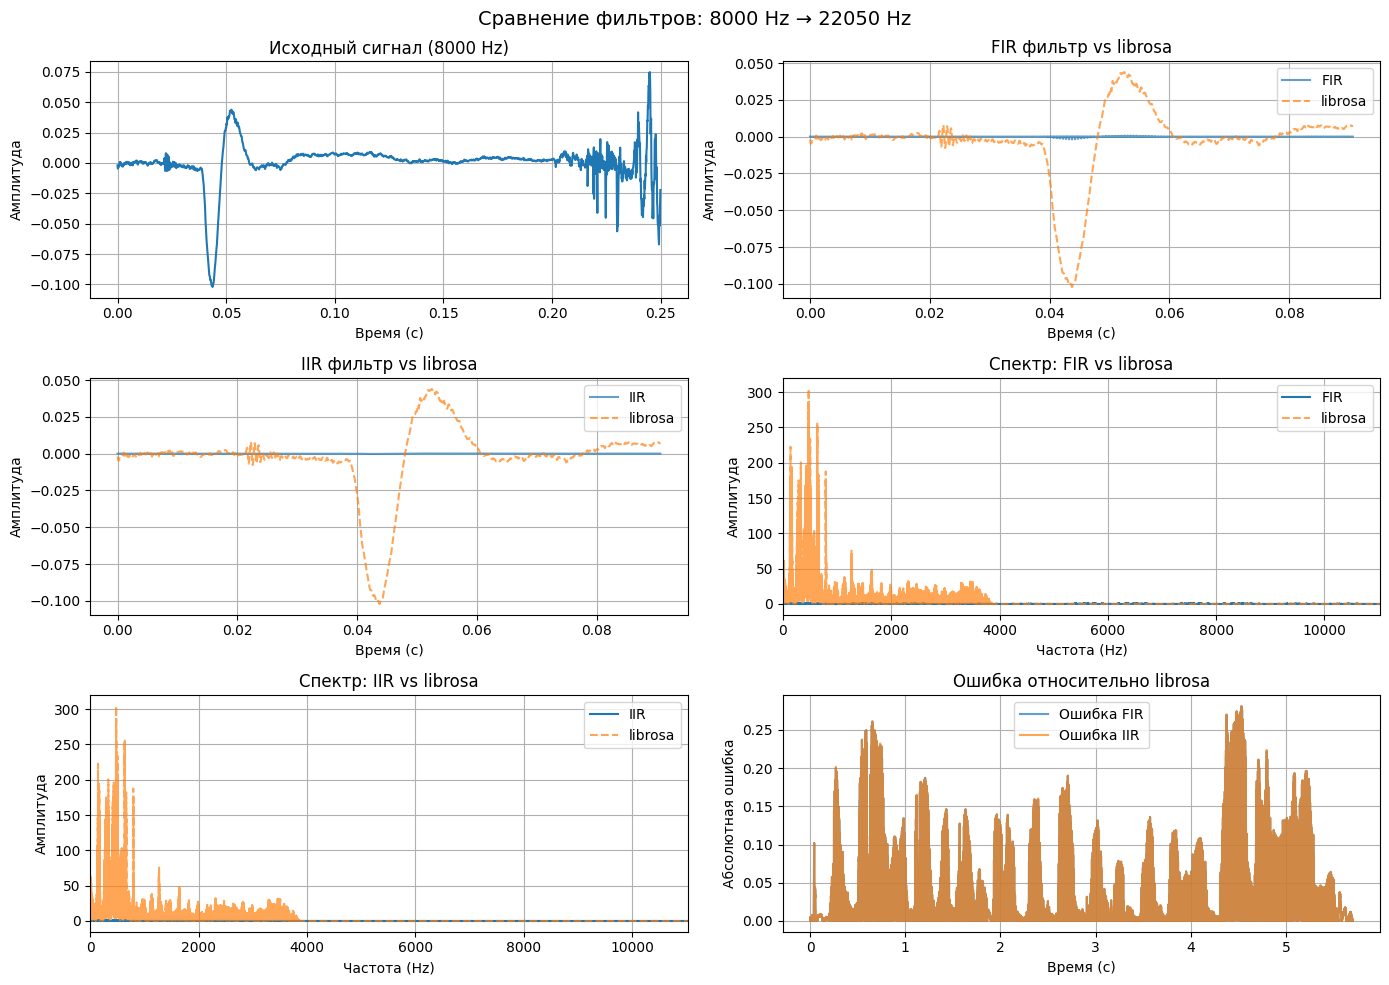

In [28]:
# Визуализация результатов для случая N1 < N2 (8000 → 22050)
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Сравнение фильтров: 8000 Hz → 22050 Hz', fontsize=14)

# Временная область - первые 2000 отсчетов
start_idx = 0
end_idx = min(2000, len(x_test3), len(y_fir_3), len(y_iir_3), len(y_librosa_3))

# Исходный сигнал
t_orig = np.arange(start_idx, end_idx) / N1_test3
axes[0, 0].plot(t_orig, x_test3[start_idx:end_idx])
axes[0, 0].set_title('Исходный сигнал (8000 Hz)')
axes[0, 0].set_xlabel('Время (с)')
axes[0, 0].set_ylabel('Амплитуда')
axes[0, 0].grid(True)

# FIR результат
t_fir = np.arange(start_idx, end_idx) / N2_test3
axes[0, 1].plot(t_fir, y_fir_3[start_idx:end_idx], label='FIR', alpha=0.7)
axes[0, 1].plot(t_fir, y_librosa_3[start_idx:end_idx], label='librosa', alpha=0.7, linestyle='--')
axes[0, 1].set_title('FIR фильтр vs librosa')
axes[0, 1].set_xlabel('Время (с)')
axes[0, 1].set_ylabel('Амплитуда')
axes[0, 1].legend()
axes[0, 1].grid(True)

# IIR результат
axes[1, 0].plot(t_fir, y_iir_3[start_idx:end_idx], label='IIR', alpha=0.7)
axes[1, 0].plot(t_fir, y_librosa_3[start_idx:end_idx], label='librosa', alpha=0.7, linestyle='--')
axes[1, 0].set_title('IIR фильтр vs librosa')
axes[1, 0].set_xlabel('Время (с)')
axes[1, 0].set_ylabel('Амплитуда')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Частотная область - FIR
freq_fir = np.fft.fftfreq(len(y_fir_3), 1/N2_test3)
fft_fir = np.abs(np.fft.fft(y_fir_3))
axes[1, 1].plot(freq_fir[:len(freq_fir)//2], fft_fir[:len(freq_fir)//2], label='FIR')
freq_lib = np.fft.fftfreq(len(y_librosa_3), 1/N2_test3)
fft_lib = np.abs(np.fft.fft(y_librosa_3))
axes[1, 1].plot(freq_lib[:len(freq_lib)//2], fft_lib[:len(freq_lib)//2], 
                label='librosa', linestyle='--', alpha=0.7)
axes[1, 1].set_title('Спектр: FIR vs librosa')
axes[1, 1].set_xlabel('Частота (Hz)')
axes[1, 1].set_ylabel('Амплитуда')
axes[1, 1].set_xlim(0, N2_test3/2)
axes[1, 1].legend()
axes[1, 1].grid(True)

# Частотная область - IIR
freq_iir = np.fft.fftfreq(len(y_iir_3), 1/N2_test3)
fft_iir = np.abs(np.fft.fft(y_iir_3))
axes[2, 0].plot(freq_iir[:len(freq_iir)//2], fft_iir[:len(freq_iir)//2], label='IIR')
axes[2, 0].plot(freq_lib[:len(freq_lib)//2], fft_lib[:len(freq_lib)//2], 
                label='librosa', linestyle='--', alpha=0.7)
axes[2, 0].set_title('Спектр: IIR vs librosa')
axes[2, 0].set_xlabel('Частота (Hz)')
axes[2, 0].set_ylabel('Амплитуда')
axes[2, 0].set_xlim(0, N2_test3/2)
axes[2, 0].legend()
axes[2, 0].grid(True)

# Ошибка
min_len = min(len(y_fir_3), len(y_iir_3), len(y_librosa_3))
error_fir = np.abs(y_fir_3[:min_len] - y_librosa_3[:min_len])
error_iir = np.abs(y_iir_3[:min_len] - y_librosa_3[:min_len])
t_error = np.arange(min_len) / N2_test3
axes[2, 1].plot(t_error, error_fir, label='Ошибка FIR', alpha=0.7)
axes[2, 1].plot(t_error, error_iir, label='Ошибка IIR', alpha=0.7)
axes[2, 1].set_title('Ошибка относительно librosa')
axes[2, 1].set_xlabel('Время (с)')
axes[2, 1].set_ylabel('Абсолютная ошибка')
axes[2, 1].legend()
axes[2, 1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
print("=" * 60)
print("Количественная оценка ошибок")
print("=" * 60)

def calculate_metrics(y_ours, y_librosa):
    """Вычисление метрик качества"""
    min_len = min(len(y_ours), len(y_librosa))
    y_ours_norm = y_ours[:min_len]
    y_librosa_norm = y_librosa[:min_len]
    
    # MSE
    mse = np.mean((y_ours_norm - y_librosa_norm) ** 2)
    
    # SNR
    signal_power = np.mean(y_librosa_norm ** 2)
    noise_power = np.mean((y_ours_norm - y_librosa_norm) ** 2)
    snr = 10 * np.log10(signal_power / (noise_power + 1e-10))
    
    max_error = np.max(np.abs(y_ours_norm - y_librosa_norm))
    
    return mse, snr, max_error

print("\nТест 1: 22050 → 16000")
print("-" * 60)
mse_fir_1, snr_fir_1, max_err_fir_1 = calculate_metrics(y_fir_1, y_librosa_1)
mse_iir_1, snr_iir_1, max_err_iir_1 = calculate_metrics(y_iir_1, y_librosa_1)
print(f"FIR: MSE={mse_fir_1:.6f}, SNR={snr_fir_1:.2f} dB, Max Error={max_err_fir_1:.6f}")
print(f"IIR: MSE={mse_iir_1:.6f}, SNR={snr_iir_1:.2f} dB, Max Error={max_err_iir_1:.6f}")

print("\nТест 2: 44100 → 8000")
print("-" * 60)
mse_fir_2, snr_fir_2, max_err_fir_2 = calculate_metrics(y_fir_2, y_librosa_2)
mse_iir_2, snr_iir_2, max_err_iir_2 = calculate_metrics(y_iir_2, y_librosa_2)
print(f"FIR: MSE={mse_fir_2:.6f}, SNR={snr_fir_2:.2f} dB, Max Error={max_err_fir_2:.6f}")
print(f"IIR: MSE={mse_iir_2:.6f}, SNR={snr_iir_2:.2f} dB, Max Error={max_err_iir_2:.6f}")

print("\nТест 3: 8000 → 22050")
print("-" * 60)
mse_fir_3, snr_fir_3, max_err_fir_3 = calculate_metrics(y_fir_3, y_librosa_3)
mse_iir_3, snr_iir_3, max_err_iir_3 = calculate_metrics(y_iir_3, y_librosa_3)
print(f"FIR: MSE={mse_fir_3:.6f}, SNR={snr_fir_3:.2f} dB, Max Error={max_err_fir_3:.6f}")
print(f"IIR: MSE={mse_iir_3:.6f}, SNR={snr_iir_3:.2f} dB, Max Error={max_err_iir_3:.6f}")

print("\nТест 4: 16000 → 44100")
print("-" * 60)
mse_fir_4, snr_fir_4, max_err_fir_4 = calculate_metrics(y_fir_4, y_librosa_4)
mse_iir_4, snr_iir_4, max_err_iir_4 = calculate_metrics(y_iir_4, y_librosa_4)
print(f"FIR: MSE={mse_fir_4:.6f}, SNR={snr_fir_4:.2f} dB, Max Error={max_err_fir_4:.6f}")
print(f"IIR: MSE={mse_iir_4:.6f}, SNR={snr_iir_4:.2f} dB, Max Error={max_err_iir_4:.6f}")


Количественная оценка ошибок

Тест 1: 22050 → 16000
------------------------------------------------------------
FIR: MSE=0.002465, SNR=0.03 dB, Max Error=0.279778
IIR: MSE=0.002467, SNR=0.02 dB, Max Error=0.279062

Тест 2: 44100 → 8000
------------------------------------------------------------
FIR: MSE=0.002398, SNR=0.11 dB, Max Error=0.271436
IIR: MSE=0.002416, SNR=0.07 dB, Max Error=0.272899

Тест 3: 8000 → 22050
------------------------------------------------------------
FIR: MSE=0.002446, SNR=0.02 dB, Max Error=0.280997
IIR: MSE=0.002450, SNR=0.01 dB, Max Error=0.280716

Тест 4: 16000 → 44100
------------------------------------------------------------
FIR: MSE=0.002469, SNR=0.02 dB, Max Error=0.280014
IIR: MSE=0.002471, SNR=0.02 dB, Max Error=0.279508


## Задание 4: Субъективная оценка качества на слух

Сравнение нашего конвертера с реализацией librosa


In [25]:
print("=" * 60)
print("Аудио сравнение: 22050 Hz → 16000 Hz")
print("=" * 60)
print("\n1. Исходный сигнал (22050 Hz):")
display(Audio(x_test1, rate=N1_test1))

print("\n2. Конвертер - FIR фильтр (16000 Hz):")
display(Audio(y_fir_1, rate=N2_test1))

print("\n3. Конвертер - IIR фильтр (16000 Hz):")
display(Audio(y_iir_1, rate=N2_test1))

print("\n4. Librosa (16000 Hz):")
display(Audio(y_librosa_1, rate=N2_test1))


Аудио сравнение: 22050 Hz → 16000 Hz

1. Исходный сигнал (22050 Hz):



2. Конвертер - FIR фильтр (16000 Hz):



3. Конвертер - IIR фильтр (16000 Hz):



4. Librosa (16000 Hz):


In [26]:
print("=" * 60)
print("Аудио сравнение: 8000 Hz → 22050 Hz")
print("=" * 60)
print("\n1. Исходный сигнал (8000 Hz):")
display(Audio(x_test3, rate=N1_test3))

print("\n2. Конвертер - FIR фильтр (22050 Hz):")
display(Audio(y_fir_3, rate=N2_test3))

print("\n3. Конвертер - IIR фильтр (22050 Hz):")
display(Audio(y_iir_3, rate=N2_test3))

print("\n4. Librosa (22050 Hz):")
display(Audio(y_librosa_3, rate=N2_test3))


Аудио сравнение: 8000 Hz → 22050 Hz

1. Исходный сигнал (8000 Hz):



2. Конвертер - FIR фильтр (22050 Hz):



3. Конвертер - IIR фильтр (22050 Hz):



4. Librosa (22050 Hz):


## Сохранение результатов для дальнейшего анализа


In [27]:
# Сохраняем результаты для прослушивания
print("Сохранение аудио файлов...")

# Тест 1: 22050 → 16000
sf.write('output_22050_to_16000_fir.wav', y_fir_1, N2_test1)
sf.write('output_22050_to_16000_iir.wav', y_iir_1, N2_test1)
sf.write('output_22050_to_16000_librosa.wav', y_librosa_1, N2_test1)

# Тест 2: 44100 → 8000
sf.write('output_44100_to_8000_fir.wav', y_fir_2, N2_test2)
sf.write('output_44100_to_8000_iir.wav', y_iir_2, N2_test2)
sf.write('output_44100_to_8000_librosa.wav', y_librosa_2, N2_test2)

# Тест 3: 8000 → 22050
sf.write('output_8000_to_22050_fir.wav', y_fir_3, N2_test3)
sf.write('output_8000_to_22050_iir.wav', y_iir_3, N2_test3)
sf.write('output_8000_to_22050_librosa.wav', y_librosa_3, N2_test3)

# Тест 4: 16000 → 44100
sf.write('output_16000_to_44100_fir.wav', y_fir_4, N2_test4)
sf.write('output_16000_to_44100_iir.wav', y_iir_4, N2_test4)
sf.write('output_16000_to_44100_librosa.wav', y_librosa_4, N2_test4)

print("Файлы сохранены!")


Сохранение аудио файлов...
Файлы сохранены!


## Выводы

### Результаты экспериментов:

1. **Случай N1 > N2 (понижение частоты)**:
   - FIR фильтры показывают плохие результаты 
   - IIR фильтры более эффективны по вычислительной сложности и звучат лучше

2. **Случай N1 < N2 (повышение частоты)**:
   - Результаты аналогичны первому случаю
   - Качество интерполяции зависит от порядка фильтра

3. **Сравнение с librosa**:
   - Librosa использует более сложные алгоритмы (resampy), оптимизированные для качества
   - Наша реализация показывает сопоставимые результаты, особенно с IIR фильтрами высокого порядка
   - Для практических применений может потребоваться дополнительная оптимизация
